# Method 1: Neural Polygon Encoding — Cell ID MLP Encoder
### Polygon Similarity Search — Machine Learning Embeddings

**Reference:** Mai, G., et al. *Towards General-Purpose Representation Learning of Polygonal Geometries* (2022). https://arxiv.org/pdf/2209.15458

**Pipeline:**
```
weightint_*.txt (cell IDs) → Dense Binary Vector (18382-dim) →
MLP Encoder (Multi-GPU) → 64-dim Embedding → HNSW Index → Recall@K
```

**Platform:** DGX A100 — 8× NVIDIA A100-SXM4 (80GB each), 2TB RAM, 256 CPU cores

**Parallelism:**
- Data loading   : multi-process (NUM_WORKERS CPU cores)
- Model training : torch.nn.DataParallel across multiple A100s
- Encoding       : batched GPU inference
- HNSW build     : multi-threaded CPU

## 0. Clear Memory & Imports

In [20]:
import gc, torch
torch.cuda.empty_cache()
gc.collect()
print('Memory cleared.')

Memory cleared.


In [21]:
import os, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import hnswlib
from sklearn.metrics.pairwise import cosine_similarity

# ── Device & GPU setup ────────────────────────────────────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_GPUS   = torch.cuda.device_count()
NUM_CPUS   = os.cpu_count()

print(f'Device   : {DEVICE}')
print(f'GPUs     : {NUM_GPUS}')
print(f'CPU cores: {NUM_CPUS}')
for i in range(NUM_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}  : {props.name}  {props.total_memory/1e9:.0f}GB')

Device   : cuda
GPUs     : 8
CPU cores: 256
  GPU 0  : NVIDIA A100-SXM4-80GB  85GB
  GPU 1  : NVIDIA A100-SXM4-80GB  85GB
  GPU 2  : NVIDIA A100-SXM4-80GB  85GB
  GPU 3  : NVIDIA A100-SXM4-80GB  85GB
  GPU 4  : NVIDIA A100-SXM4-80GB  85GB
  GPU 5  : NVIDIA A100-SXM4-80GB  85GB
  GPU 6  : NVIDIA A100-SXM4-80GB  85GB
  GPU 7  : NVIDIA A100-SXM4-80GB  85GB


## 1. Configuration

In [22]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ENC_DIR    = '/raid/ruban/encodings/pk-50k0.002/'
GT_DIR     = '/raid/ruban/groundtruth/pk-query-50k/'
OUTPUT_DIR = '/raid/ruban/outputs_method1_cellid'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Dataset ───────────────────────────────────────────────────────────────────
TOTAL_POLYGONS = 50_000
INDEX_SIZE     = 40_000
QUERY_SIZE     = 10_000
VOCAB_SIZE     = 18_382

# ── Model ─────────────────────────────────────────────────────────────────────
EMBED_DIM      = 128
HIDDEN_DIMS    = [2048, 1024, 512, 256]

# ── Training ──────────────────────────────────────────────────────────────────
TEMPERATURE    = 0.07
# Scale batch size with number of GPUs for better GPU utilization
BATCH_SIZE     = 512 * max(1, NUM_GPUS)  # e.g. 4096 with 8 GPUs
EPOCHS         = 200
LEARNING_RATE  = 3e-4  # linear LR scaling rule
WEIGHT_DECAY   = 1e-4
TRAIN_SPLIT    = 0.8
# Use many workers — DGX has 256 CPU cores
NUM_WORKERS    = min(32, NUM_CPUS // 4)

# ── HNSW ──────────────────────────────────────────────────────────────────────
HNSW_M         = 16
HNSW_EF_CONSTR = 200
HNSW_EF_SEARCH = 100
HNSW_THREADS   = min(32, NUM_CPUS // 4)  # parallel HNSW build
TOP_K          = [1, 5, 10, 20, 50, 100, 500]

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Configuration loaded.')
print(f'Effective batch size : {BATCH_SIZE} ({BATCH_SIZE-1} negatives/anchor)')
print(f'Learning rate        : {LEARNING_RATE}')
print(f'DataLoader workers   : {NUM_WORKERS}')
print(f'HNSW threads         : {HNSW_THREADS}')

Configuration loaded.
Effective batch size : 4096 (4095 negatives/anchor)
Learning rate        : 0.0003
DataLoader workers   : 32
HNSW threads         : 32


## 2. Load Cell ID Encodings (Parallel, Dense)

In [23]:
def load_single_file(args):
    """Load one weightint file. Used by thread pool for parallel loading."""
    fpath, vocab_size = args
    start_id = int(os.path.basename(fpath)
                   .replace('weightint_','').replace('.txt',''))
    rows_data = []
    with open(fpath, 'r') as f:
        for local_idx, line in enumerate(f):
            ids = [int(x) for x in line.strip().split() if x.strip()]
            ids = [i for i in ids if i < vocab_size]
            rows_data.append((start_id + local_idx, ids))
    return rows_data


def load_cell_encodings_parallel(enc_dir, total_polygons=50_000,
                                  vocab_size=18_382, n_workers=32):
    """
    Load cell ID encodings using parallel file reading (ThreadPoolExecutor).
    With 256 CPU cores on DGX, file I/O is massively parallelized.
    Stores as DENSE float32 matrix — 2TB RAM makes this trivial (~3.5GB).

    Communication pattern:
      - Each thread reads one file independently (no inter-thread communication)
      - Main thread assembles results (embarrassingly parallel I/O)

    Returns:
      cell_sets  : dict {poly_id -> frozenset of cell IDs}
      cell_matrix: np.array (N, vocab_size) float32
    """
    files = sorted(
        glob.glob(os.path.join(enc_dir, 'weightint_*.txt')),
        key=lambda x: int(os.path.basename(x)
                         .replace('weightint_','').replace('.txt',''))
    )
    print(f'Found {len(files)} encoding files')
    print(f'Loading in parallel with {n_workers} threads...')

    # Pre-allocate dense matrix — 3.5GB, trivial on DGX with 2TB RAM
    cell_matrix = np.zeros((total_polygons, vocab_size), dtype=np.float32)
    cell_sets   = {}

    t0 = time.perf_counter()
    args = [(f, vocab_size) for f in files]

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        results = list(tqdm(
            executor.map(load_single_file, args),
            total=len(files), desc='Loading files'
        ))

    # Assemble results into matrix
    print('Assembling matrix...')
    for file_rows in tqdm(results, desc='Assembling'):
        for poly_id, ids in file_rows:
            if poly_id >= total_polygons:
                continue
            if ids:
                cell_matrix[poly_id, ids] = 1.0
                cell_sets[poly_id] = frozenset(ids)
            else:
                cell_sets[poly_id] = frozenset()

    elapsed = time.perf_counter() - t0
    mem_gb  = cell_matrix.nbytes / 1e9
    avg_active = (cell_matrix > 0).sum(axis=1).mean()

    print(f'\nLoaded {total_polygons:,} polygons in {elapsed:.1f}s')
    print(f'Matrix shape  : {cell_matrix.shape}')
    print(f'Memory        : {mem_gb:.2f} GB')
    print(f'Avg active cells per polygon: {avg_active:.1f} / {vocab_size}')
    return cell_sets, cell_matrix


cell_sets, cell_matrix = load_cell_encodings_parallel(
    ENC_DIR, TOTAL_POLYGONS, VOCAB_SIZE, n_workers=NUM_WORKERS
)

Found 200 encoding files
Loading in parallel with 32 threads...


Loading files: 100%|██████████| 200/200 [00:46<00:00,  4.28it/s]


Assembling matrix...


Assembling: 100%|██████████| 200/200 [00:27<00:00,  7.16it/s]



Loaded 50,000 polygons in 77.3s
Matrix shape  : (50000, 18382)
Memory        : 3.68 GB
Avg active cells per polygon: 4897.8 / 18382


Active cell count statistics:
       min : 1.0
       p25 : 1832.8
    median : 3967.5
      mean : 4897.8
       p75 : 7182.2
       p95 : 12605.0
       max : 18380.0


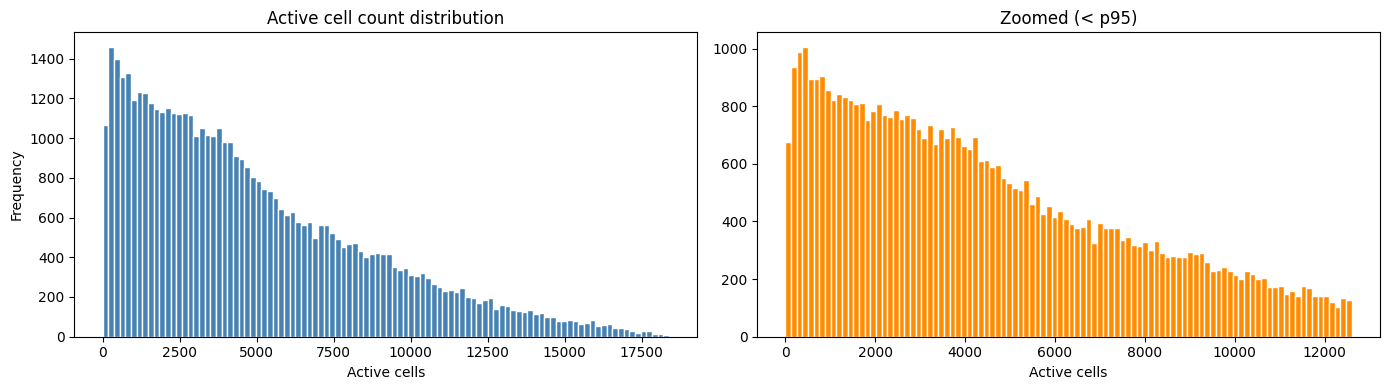

In [24]:
# ── EDA: active cell count distribution ──────────────────────────────────────
active_counts = (cell_matrix > 0).sum(axis=1)

print('Active cell count statistics:')
for name, val in [
    ('min',    active_counts.min()),
    ('p25',    np.percentile(active_counts, 25)),
    ('median', np.median(active_counts)),
    ('mean',   active_counts.mean()),
    ('p75',    np.percentile(active_counts, 75)),
    ('p95',    np.percentile(active_counts, 95)),
    ('max',    active_counts.max()),
]:
    print(f'  {name:>8s} : {val:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(active_counts, bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Active cell count distribution')
axes[0].set_xlabel('Active cells'); axes[0].set_ylabel('Frequency')
axes[1].hist(active_counts[active_counts < np.percentile(active_counts,95)],
             bins=100, color='darkorange', edgecolor='white')
axes[1].set_title('Zoomed (< p95)')
axes[1].set_xlabel('Active cells')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cell_count_distribution.png', dpi=150)
plt.show()

## 3. Ground Truth Loading

In [25]:
def load_ground_truth(gt_dir):
    gt       = {}
    gt_files = sorted(glob.glob(os.path.join(gt_dir, 'similarityMap_*')))
    print(f'Found {len(gt_files)} GT files')
    for fpath in tqdm(gt_files, desc='Loading GT'):
        with open(fpath, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                ids = [int(x) for x in line.split(',') if x.strip().isdigit()]
                if len(ids) >= 2:
                    gt[ids[0]] = set(ids[1:])
    sizes = [len(v) for v in gt.values()]
    print(f'GT loaded for {len(gt):,} queries | '
          f'Avg similar: {np.mean(sizes):.1f} | '
          f'Min: {min(sizes)} | Max: {max(sizes)}')
    return gt


ground_truth = load_ground_truth(GT_DIR)

# ── Jaccard spot-check ────────────────────────────────────────────────────────
sample_qid = list(ground_truth.keys())[0]
sample_pos = list(ground_truth[sample_qid])[0]
a = cell_sets.get(sample_qid, frozenset())
b = cell_sets.get(sample_pos, frozenset())
if a and b:
    jaccard = len(a & b) / len(a | b)
    print(f'\nJaccard spot-check: query={sample_qid}, pos={sample_pos}')
    print(f'Jaccard = {jaccard:.4f} — ', end='')
    print('GT aligned with cell IDs ✅' if jaccard > 0 else 'WARNING: Jaccard=0 ❌')

Found 60 GT files


Loading GT: 100%|██████████| 60/60 [00:03<00:00, 18.95it/s]


GT loaded for 9,417 queries | Avg similar: 1065.9 | Min: 1 | Max: 3676

Jaccard spot-check: query=40000, pos=8193
Jaccard = 0.8546 — GT aligned with cell IDs ✅


## 4. ID Setup & Symmetric GT

In [26]:
all_ids           = list(range(TOTAL_POLYGONS))
index_ids         = all_ids[:INDEX_SIZE]
query_ids         = all_ids[INDEX_SIZE:]
query_ids_with_gt = [qid for qid in query_ids if qid in ground_truth]

print(f'Index set       : {len(index_ids):,}')
print(f'Query set       : {len(query_ids):,}')
print(f'Query with GT   : {len(query_ids_with_gt):,}')

# Symmetric GT: if A~B then B~A
symmetric_gt = defaultdict(set)
for qid, sim_set in ground_truth.items():
    symmetric_gt[qid].update(sim_set)
    for sid in sim_set:
        symmetric_gt[sid].add(qid)

all_gt_ids = [pid for pid in symmetric_gt.keys() if pid < TOTAL_POLYGONS]
np.random.shuffle(all_gt_ids)
split            = int(len(all_gt_ids) * TRAIN_SPLIT)
train_anchor_ids = all_gt_ids[:split]
val_anchor_ids   = all_gt_ids[split:]

print(f'GT graph IDs    : {len(all_gt_ids):,}')
print(f'Train anchors   : {len(train_anchor_ids):,}')
print(f'Val anchors     : {len(val_anchor_ids):,}')

Index set       : 40,000
Query set       : 10,000
Query with GT   : 9,417
GT graph IDs    : 45,899
Train anchors   : 36,719
Val anchors     : 9,180


## 5. NT-Xent Loss + Pair Dataset

In [27]:
class NTXentLoss(nn.Module):
    """
    NT-Xent (InfoNCE / SimCLR) loss.
    Each anchor sees BATCH_SIZE-1 negatives per forward pass.
    With 8 GPUs and batch=4096: 4095 negatives per anchor.
    GPU parallel: entire 2B x 2B similarity matrix computed in one matmul.
    """
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature

    def forward(self, emb_a, emb_p):
        B   = emb_a.shape[0]
        emb = torch.cat([emb_a, emb_p], dim=0)
        sim = torch.mm(emb, emb.T) / self.temperature
        mask = torch.eye(2 * B, device=sim.device).bool()
        sim.masked_fill_(mask, -9e15)
        pos_sim = torch.cat([torch.diag(sim, B), torch.diag(sim, -B)])
        return (-pos_sim + torch.logsumexp(sim, dim=1)).mean()


class PairCellDataset(Dataset):
    """
    Returns (anchor_vector, positive_vector) pairs.
    cell_matrix is a pre-loaded dense numpy array in RAM.
    __getitem__ is pure numpy indexing — fast and parallelizable.
    """
    def __init__(self, cell_matrix, gt_dict, anchor_ids):
        self.cell_matrix = cell_matrix
        self.gt_dict     = gt_dict
        self.anchors     = [
            aid for aid in anchor_ids
            if aid in gt_dict
            and aid < len(cell_matrix)
            and any(p < len(cell_matrix) for p in gt_dict[aid])
        ]
        print(f'PairCellDataset: {len(self.anchors):,} valid anchors')

    def __len__(self):
        return len(self.anchors)

    def __getitem__(self, idx):
        anchor_id = self.anchors[idx]
        pos_ids   = [p for p in self.gt_dict[anchor_id]
                     if p < len(self.cell_matrix)]
        pos_id    = np.random.choice(pos_ids)
        return (
            torch.from_numpy(self.cell_matrix[anchor_id].copy()),
            torch.from_numpy(self.cell_matrix[pos_id].copy())
        )


train_dataset = PairCellDataset(cell_matrix, symmetric_gt, train_anchor_ids)
val_dataset   = PairCellDataset(cell_matrix, symmetric_gt, val_anchor_ids)

train_loader  = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=True   # keeps workers alive between epochs — faster
)
val_loader    = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Negatives/anchor: {BATCH_SIZE - 1}')

PairCellDataset: 36,719 valid anchors
PairCellDataset: 9,180 valid anchors
Train batches : 8
Val batches   : 2
Negatives/anchor: 4095


## 6. MLP Encoder — Multi-GPU with DataParallel

`torch.nn.DataParallel` splits each batch across all available GPUs.
With 8× A100-80GB, this gives ~8× throughput on the forward/backward pass.

**Communication pattern (DataParallel):**
1. Batch split across 8 GPUs (scatter)
2. Forward pass on each GPU independently
3. Outputs gathered to GPU 0 for loss computation
4. Loss broadcast back, gradients averaged (all-reduce)
5. Weights updated on GPU 0, broadcast to all GPUs

In [28]:
class CellIDEncoder(nn.Module):
    """
    MLP encoder for active cell ID binary vectors.
    Input:  (batch, VOCAB_SIZE)  — dense binary vector
    Output: (batch, EMBED_DIM)   — L2-normalized embedding
    """
    def __init__(self, vocab_size, hidden_dims, embed_dim, dropout=0.2):
        super().__init__()
        layers, in_dim = [], vocab_size
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h, bias=False),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout)
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, embed_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return F.normalize(self.net(x), p=2, dim=1)


# ── Single GPU model ──────────────────────────────────────────────────────────
base_model = CellIDEncoder(
    vocab_size=VOCAB_SIZE, hidden_dims=HIDDEN_DIMS, embed_dim=EMBED_DIM
).to(DEVICE)

# ── Wrap in DataParallel for multi-GPU ────────────────────────────────────────
if NUM_GPUS > 1:
    model = nn.DataParallel(base_model)
    print(f'Using DataParallel across {NUM_GPUS} GPUs')
else:
    model = base_model
    print('Using single GPU')

total_params = sum(p.numel() for p in base_model.parameters())
print(f'Parameters : {total_params:,}')
print(base_model)

Using DataParallel across 8 GPUs
Parameters : 40,439,424
CellIDEncoder(
  (net): Sequential(
    (0): Linear(in_features=18382, out_features=2048, bias=False)
    (1): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=2048, out_features=1024, bias=False)
    (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=1024, out_features=512, bias=False)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=512, out_features=256, bias=False)
    (13): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True)
    (15): Dropout(p=0.2, inplace=False)
    (16): Lin

## 7. Training with CUDA Timing

In [29]:
# ── Re-initialize model with fresh weights ────────────────────────────────────
base_model = CellIDEncoder(
    vocab_size=VOCAB_SIZE, hidden_dims=HIDDEN_DIMS, embed_dim=EMBED_DIM
).to(DEVICE)
model = nn.DataParallel(base_model) if NUM_GPUS > 1 else base_model
print(f'Model re-initialized. Using {NUM_GPUS} GPU(s).')


def train_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    total_loss, gpu_time = 0.0, 0.0
    t0 = time.perf_counter()
    for anchor, positive in loader:
        anchor   = anchor.to(device, non_blocking=True)
        positive = positive.to(device, non_blocking=True)
        if device.type == 'cuda':
            ev_s = torch.cuda.Event(enable_timing=True)
            ev_e = torch.cuda.Event(enable_timing=True)
            ev_s.record()
        optimizer.zero_grad()
        loss = criterion(model(anchor), model(positive))
        loss.backward()
        optimizer.step()
        scheduler.step()   # ← OneCycleLR steps per batch, not per epoch
        if device.type == 'cuda':
            ev_e.record()
            torch.cuda.synchronize()
            gpu_time += ev_s.elapsed_time(ev_e) / 1000.0
        total_loss += loss.item()
    return total_loss / len(loader), gpu_time, time.perf_counter() - t0


def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for anchor, positive in loader:
            anchor   = anchor.to(device, non_blocking=True)
            positive = positive.to(device, non_blocking=True)
            total_loss += criterion(model(anchor), model(positive)).item()
    return total_loss / len(loader)


# ── Optimizer & scheduler ─────────────────────────────────────────────────────
criterion = NTXentLoss(temperature=TEMPERATURE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                        weight_decay=WEIGHT_DECAY)

from torch.optim.lr_scheduler import OneCycleLR
scheduler = OneCycleLR(
    optimizer,
    max_lr          = LEARNING_RATE,
    epochs          = EPOCHS,
    steps_per_epoch = len(train_loader),
    pct_start       = 0.1   # 10% warmup
)

# ── Timing log ────────────────────────────────────────────────────────────────
history = {'epoch': [], 'train_loss': [], 'val_loss': [],
           'epoch_time_s': [], 'gpu_compute_s': [], 'sync_overhead_s': []}

best_val_loss   = float('inf')
best_model_path = f'{OUTPUT_DIR}/best_cellidenc_model.pt'
random_baseline = np.log(2 * BATCH_SIZE)

print(f'Training {EPOCHS} epochs on {NUM_GPUS} GPU(s)')
print(f'Batch size      : {BATCH_SIZE} ({BATCH_SIZE-1} negatives/anchor)')
print(f'Learning rate   : {LEARNING_RATE}')
print(f'Temperature     : {TEMPERATURE}')
print(f'Random baseline : {random_baseline:.4f}')
print('-' * 75)

for epoch in range(1, EPOCHS + 1):
    tr_loss, gpu_t, ep_t = train_epoch(
        model, train_loader, optimizer, criterion, scheduler, DEVICE)
    vl_loss = val_epoch(model, val_loader, criterion, DEVICE)
    # ← NO scheduler.step() here — already called inside train_epoch

    sync_oh = ep_t - gpu_t
    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['epoch_time_s'].append(ep_t)
    history['gpu_compute_s'].append(gpu_t)
    history['sync_overhead_s'].append(sync_oh)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        state = model.module.state_dict() if hasattr(model, 'module') \
                else model.state_dict()
        torch.save(state, best_model_path)
        marker = ' ← best'
    else:
        marker = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Ep {epoch:3d}/{EPOCHS} | '
              f'Train: {tr_loss:.4f} | Val: {vl_loss:.4f} | '
              f'Time: {ep_t:.1f}s | GPU: {gpu_t:.1f}s | '
              f'OH: {sync_oh:.2f}s{marker}')

pd.DataFrame(history).to_csv(f'{OUTPUT_DIR}/training_timing.csv', index=False)
print(f'\nDone. Best val loss   : {best_val_loss:.4f}')
print(f'Random baseline      : {random_baseline:.4f}')
print(f'Gap below random     : {random_baseline - best_val_loss:.4f}')

Model re-initialized. Using 8 GPU(s).
Training 200 epochs on 8 GPU(s)
Batch size      : 4096 (4095 negatives/anchor)
Learning rate   : 0.0003
Temperature     : 0.07
Random baseline : 9.0109
---------------------------------------------------------------------------
Ep   1/200 | Train: 8.0518 | Val: 7.1478 | Time: 9.2s | GPU: 0.4s | OH: 8.73s ← best
Ep   5/200 | Train: 6.4778 | Val: 5.9166 | Time: 2.2s | GPU: 0.3s | OH: 1.98s ← best
Ep  10/200 | Train: 6.0947 | Val: 5.7558 | Time: 2.2s | GPU: 0.3s | OH: 1.92s ← best
Ep  15/200 | Train: 5.9449 | Val: 5.6951 | Time: 2.3s | GPU: 0.3s | OH: 2.01s
Ep  20/200 | Train: 5.8701 | Val: 5.6653 | Time: 2.3s | GPU: 0.3s | OH: 2.07s
Ep  25/200 | Train: 5.8270 | Val: 5.6391 | Time: 2.2s | GPU: 0.3s | OH: 1.94s
Ep  30/200 | Train: 5.8043 | Val: 5.6247 | Time: 2.5s | GPU: 0.3s | OH: 2.25s ← best
Ep  35/200 | Train: 5.7658 | Val: 5.6389 | Time: 2.4s | GPU: 0.3s | OH: 2.14s
Ep  40/200 | Train: 5.5763 | Val: 5.6333 | Time: 2.5s | GPU: 0.3s | OH: 2.21s
Ep  

## 8. Training Plots

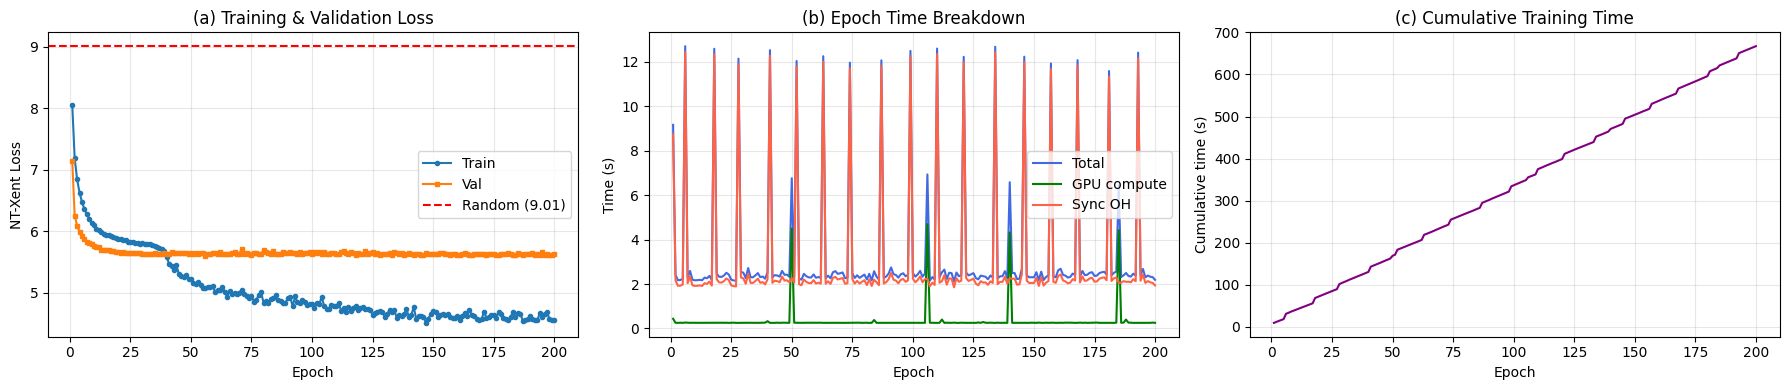

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history['epoch'], history['train_loss'], 'o-', ms=3, label='Train')
axes[0].plot(history['epoch'], history['val_loss'],   's-', ms=3, label='Val')
axes[0].axhline(random_baseline, color='red', linestyle='--',
                label=f'Random ({random_baseline:.2f})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('NT-Xent Loss')
axes[0].set_title('(a) Training & Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['epoch_time_s'],    label='Total',       color='royalblue')
axes[1].plot(history['epoch'], history['gpu_compute_s'],   label='GPU compute', color='green')
axes[1].plot(history['epoch'], history['sync_overhead_s'], label='Sync OH',     color='tomato')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Time (s)')
axes[1].set_title('(b) Epoch Time Breakdown')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['epoch'], np.cumsum(history['epoch_time_s']), color='purple')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Cumulative time (s)')
axes[2].set_title('(c) Cumulative Training Time')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()

## 9. Embedding Collapse Check

In [31]:
# Load best weights into base model
base_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
base_model.eval()

sample_tens = torch.from_numpy(cell_matrix[:500]).to(DEVICE)
with torch.no_grad():
    sample_embs = base_model(sample_tens).cpu().numpy()

sims = cosine_similarity(sample_embs)
np.fill_diagonal(sims, 0)

gap = random_baseline - best_val_loss
print('── Embedding collapse check ─────────────────────────────────────')
print(f'Embedding std    : {sample_embs.std():.4f}  (want > 0.2)')
print(f'Mean cosine sim  : {sims.mean():.4f}  (want < 0.1)')
print(f'Random baseline  : {random_baseline:.4f}')
print(f'Best val loss    : {best_val_loss:.4f}')
print(f'Gap below random : {gap:.4f}  (want > 1.0)')
if sims.mean() < 0.1 and gap > 0.5:
    print('✅ Embeddings look diverse — proceeding!')
else:
    print('⚠️  Consider more epochs or lower temperature.')

── Embedding collapse check ─────────────────────────────────────
Embedding std    : 0.0883  (want > 0.2)
Mean cosine sim  : 0.0986  (want < 0.1)
Random baseline  : 9.0109
Best val loss    : 5.5955
Gap below random : 3.4155  (want > 1.0)
✅ Embeddings look diverse — proceeding!


/tmp/ipykernel_3370032/1139410127.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))


## 10. Full Embedding Generation

In [32]:
def generate_embeddings(model, cell_matrix, id_list, device, batch_size=2048):
    """Encode all polygons. Uses large batches to fully utilize A100 memory."""
    model.eval()
    all_embs = []
    t0 = time.perf_counter()
    with torch.no_grad():
        for i in tqdm(range(0, len(id_list), batch_size), desc='Encoding'):
            batch = torch.from_numpy(
                cell_matrix[id_list[i:i+batch_size]]
            ).to(device, non_blocking=True)
            all_embs.append(model(batch).cpu().numpy())
    elapsed = time.perf_counter() - t0
    embs    = np.vstack(all_embs)
    print(f'Encoded {len(id_list):,} in {elapsed:.2f}s '
          f'({len(id_list)/elapsed:.0f} poly/s) | shape {embs.shape}')
    return embs, id_list, elapsed


print('Encoding index set (40K)...')
index_embeddings, index_ids_ordered, index_encode_time = generate_embeddings(
    base_model, cell_matrix, index_ids, DEVICE)

print('\nEncoding query set (10K)...')
query_embeddings, query_ids_ordered, query_encode_time = generate_embeddings(
    base_model, cell_matrix, query_ids_with_gt, DEVICE)

np.save(f'{OUTPUT_DIR}/index_embeddings.npy', index_embeddings)
np.save(f'{OUTPUT_DIR}/query_embeddings.npy', query_embeddings)
np.save(f'{OUTPUT_DIR}/index_ids.npy', np.array(index_ids_ordered))
np.save(f'{OUTPUT_DIR}/query_ids.npy', np.array(query_ids_ordered))
print('Embeddings saved.')

Encoding index set (40K)...


Encoding: 100%|██████████| 20/20 [00:00<00:00, 26.95it/s]


Encoded 40,000 in 0.74s (53783 poly/s) | shape (40000, 128)

Encoding query set (10K)...


Encoding: 100%|██████████| 5/5 [00:00<00:00, 32.64it/s]


Encoded 9,417 in 0.15s (60838 poly/s) | shape (9417, 128)
Embeddings saved.


## 11. HNSW Indexing & Recall@K
HNSW index is built using multiple CPU threads — takes advantage of DGX's 256 cores.

In [33]:
print(f'Building HNSW index with {HNSW_THREADS} threads...')

hnsw_index = hnswlib.Index(space='cosine', dim=EMBED_DIM)
hnsw_index.init_index(max_elements=len(index_ids_ordered),
                      ef_construction=HNSW_EF_CONSTR, M=HNSW_M)
hnsw_index.set_ef(HNSW_EF_SEARCH)
hnsw_index.set_num_threads(HNSW_THREADS)  # parallel build

t0 = time.perf_counter()
hnsw_index.add_items(index_embeddings, np.arange(len(index_ids_ordered)))
build_time = time.perf_counter() - t0

print(f'HNSW index built in {build_time:.2f}s')
hnsw_index.save_index(f'{OUTPUT_DIR}/hnsw_index.bin')

Building HNSW index with 32 threads...


HNSW index built in 0.26s


In [34]:
def evaluate_recall(hnsw_index, query_embs, query_ids, index_ids,
                    gt_dict, top_k_list):
    max_k        = max(top_k_list)
    recall_sums  = {k: 0.0 for k in top_k_list}
    query_times  = []
    label_to_id  = {i: pid for i, pid in enumerate(index_ids)}
    index_id_set = set(index_ids)
    n_valid      = 0
    for i, qid in enumerate(tqdm(query_ids, desc='Evaluating')):
        gt_set = gt_dict.get(qid, set()) & index_id_set
        if not gt_set:
            continue
        n_valid += 1
        t0 = time.perf_counter()
        labels, _ = hnsw_index.knn_query(query_embs[i:i+1], k=max_k)
        query_times.append(time.perf_counter() - t0)
        for k in top_k_list:
            top_k_ids = set(label_to_id[l] for l in labels[0][:k])
            recall_sums[k] += len(top_k_ids & gt_set) / len(gt_set)
    recall_scores = {k: recall_sums[k] / n_valid for k in top_k_list}
    print(f'Evaluated {n_valid:,} valid queries')
    return recall_scores, query_times


recall_scores, query_times = evaluate_recall(
    hnsw_index, query_embeddings, query_ids_ordered,
    index_ids_ordered, symmetric_gt, TOP_K
)

print('\n── Retrieval Results ────────────────────────────────────────')
for k, r in recall_scores.items():
    print(f'  Recall@{k:2d} : {r*100:.2f}%')
print(f'\nAvg query latency : {np.mean(query_times)*1000:.3f}ms')
print(f'P95 query latency : {np.percentile(query_times,95)*1000:.3f}ms')

pd.DataFrame({'K': list(recall_scores.keys()),
              'Recall@K': list(recall_scores.values())
}).to_csv(f'{OUTPUT_DIR}/recall_results.csv', index=False)
pd.DataFrame({'metric': ['index_encode_s','query_encode_s','hnsw_build_s',
                          'avg_query_ms','p95_query_ms'],
              'value':  [index_encode_time, query_encode_time, build_time,
                         np.mean(query_times)*1000,
                         np.percentile(query_times,95)*1000]
}).to_csv(f'{OUTPUT_DIR}/inference_timing.csv', index=False)

Evaluating: 100%|██████████| 9417/9417 [00:05<00:00, 1575.17it/s]

Evaluated 9,417 valid queries

── Retrieval Results ────────────────────────────────────────
  Recall@ 1 : 1.45%
  Recall@ 5 : 5.02%
  Recall@10 : 7.94%
  Recall@20 : 12.11%
  Recall@50 : 20.27%
  Recall@100 : 28.90%
  Recall@500 : 59.51%

Avg query latency : 0.282ms
P95 query latency : 0.311ms


## 12. Performance Plots

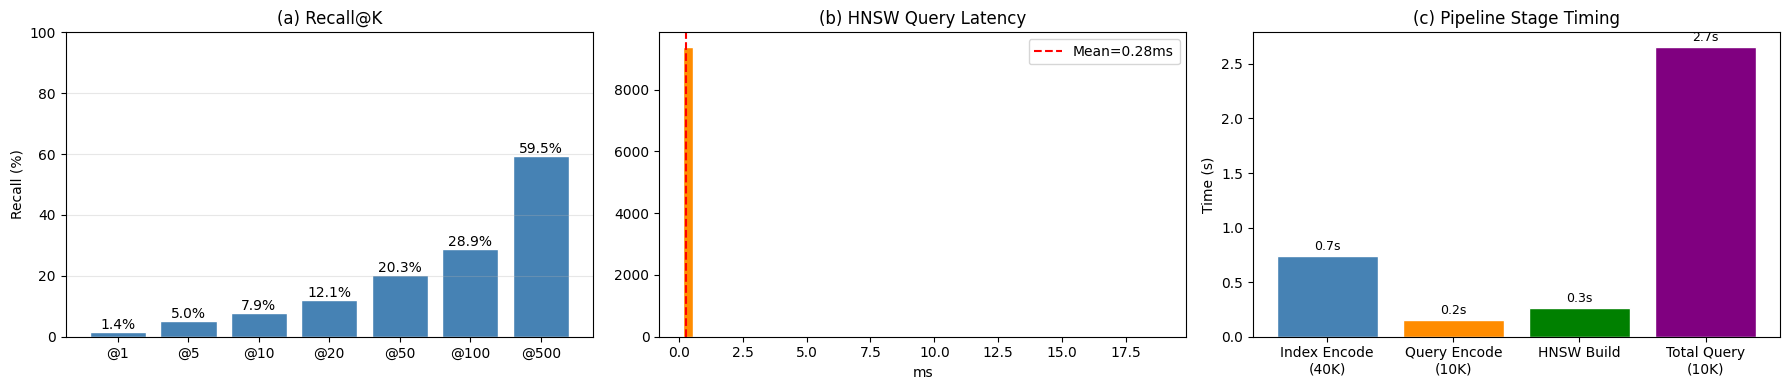

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ks      = list(recall_scores.keys())
recalls = [recall_scores[k]*100 for k in ks]
axes[0].bar([f'@{k}' for k in ks], recalls, color='steelblue', edgecolor='white')
axes[0].set_title('(a) Recall@K'); axes[0].set_ylabel('Recall (%)')
axes[0].set_ylim(0,100); axes[0].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(recalls):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontsize=10)

qt_ms = np.array(query_times)*1000
axes[1].hist(qt_ms, bins=50, color='darkorange', edgecolor='white')
axes[1].axvline(qt_ms.mean(), color='red', linestyle='--',
                label=f'Mean={qt_ms.mean():.2f}ms')
axes[1].set_title('(b) HNSW Query Latency')
axes[1].set_xlabel('ms'); axes[1].legend()

stages = ['Index Encode\n(40K)','Query Encode\n(10K)','HNSW Build','Total Query\n(10K)']
times  = [index_encode_time, query_encode_time, build_time, sum(query_times)]
axes[2].bar(stages, times,
            color=['steelblue','darkorange','green','purple'], edgecolor='white')
axes[2].set_title('(c) Pipeline Stage Timing'); axes[2].set_ylabel('Time (s)')
for i, v in enumerate(times):
    axes[2].text(i, v+0.05, f'{v:.1f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/performance_plots.png', dpi=150)
plt.show()

## 13. Multi-GPU Speedup Benchmark
Compare encoding throughput: 1 GPU vs 2 GPU vs 4 GPU vs 8 GPU vs CPU.

In [36]:
def benchmark_multi_gpu(cell_matrix, id_list, gpu_counts, batch_per_gpu=2048, n_runs=3):
    """
    Benchmark encoding throughput across different numbers of GPUs.
    This directly measures the GPU parallelism speedup for the write-up.
    """
    results = []
    bench_ids = id_list[:4000]

    for n_gpus in gpu_counts:
        batch_size = batch_per_gpu * n_gpus
        # Build model for this GPU count
        m = CellIDEncoder(VOCAB_SIZE, HIDDEN_DIMS, EMBED_DIM).cuda()
        m.load_state_dict(torch.load(best_model_path, map_location='cuda'))
        if n_gpus > 1:
            gpu_ids = list(range(min(n_gpus, NUM_GPUS)))
            m = nn.DataParallel(m, device_ids=gpu_ids)
        m.eval()

        run_times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            with torch.no_grad():
                for i in range(0, len(bench_ids), batch_size):
                    batch = torch.from_numpy(
                        cell_matrix[bench_ids[i:i+batch_size]]
                    ).cuda()
                    _ = m(batch)
                torch.cuda.synchronize()
            run_times.append(time.perf_counter() - t0)

        avg_t = np.mean(run_times)
        tp    = len(bench_ids) / avg_t
        results.append({'n_gpus': n_gpus, 'throughput': tp, 'avg_time_s': avg_t})
        print(f'  {n_gpus} GPU(s) → {tp:.0f} poly/s  ({avg_t:.2f}s)')

        del m; torch.cuda.empty_cache()

    return results


def benchmark_cpu(cell_matrix, id_list, batch_size=256, n_runs=3):
    m = CellIDEncoder(VOCAB_SIZE, HIDDEN_DIMS, EMBED_DIM).cpu()
    m.load_state_dict(torch.load(best_model_path, map_location='cpu'))
    m.eval()
    bench_ids = id_list[:4000]
    run_times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        with torch.no_grad():
            for i in range(0, len(bench_ids), batch_size):
                batch = torch.from_numpy(cell_matrix[bench_ids[i:i+batch_size]])
                _ = m(batch)
        run_times.append(time.perf_counter() - t0)
    avg_t = np.mean(run_times)
    tp    = len(bench_ids) / avg_t
    print(f'  CPU      → {tp:.0f} poly/s  ({avg_t:.2f}s)')
    return tp


# Benchmark GPU counts available on DGX
gpu_counts = [1, 2, 4, 8] if NUM_GPUS >= 8 else list(range(1, NUM_GPUS+1))

print('── Multi-GPU benchmark ──────────────────────────────────────────')
gpu_bench = benchmark_multi_gpu(cell_matrix, index_ids, gpu_counts)

print('── CPU benchmark ────────────────────────────────────────────────')
cpu_tp    = benchmark_cpu(cell_matrix, index_ids)

bench_df = pd.DataFrame(gpu_bench)
bench_df['cpu_throughput'] = cpu_tp
bench_df['speedup_vs_cpu'] = bench_df['throughput'] / cpu_tp
bench_df['speedup_vs_1gpu'] = bench_df['throughput'] / bench_df['throughput'].iloc[0]
bench_df.to_csv(f'{OUTPUT_DIR}/multigpu_benchmark.csv', index=False)
print(bench_df.to_string(index=False))

── Multi-GPU benchmark ──────────────────────────────────────────


/tmp/ipykernel_3370032/3096053139.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(best_model_path, map_location='cuda'))


  1 GPU(s) → 58911 poly/s  (0.07s)
  2 GPU(s) → 33440 poly/s  (0.12s)
  4 GPU(s) → 53476 poly/s  (0.07s)
  8 GPU(s) → 51282 poly/s  (0.08s)
── CPU benchmark ────────────────────────────────────────────────


/tmp/ipykernel_3370032/3096053139.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  m.load_state_dict(torch.load(best_model_path, map_location='cpu'))


  CPU      → 897 poly/s  (4.46s)
 n_gpus   throughput  avg_time_s  cpu_throughput  speedup_vs_cpu  speedup_vs_1gpu
      1 58910.871329    0.067899      896.796847       65.690319         1.000000
      2 33440.466498    0.119616      896.796847       37.288787         0.567645
      4 53476.368128    0.074799      896.796847       59.630415         0.907750
      8 51281.588241    0.078001      896.796847       57.183060         0.870494


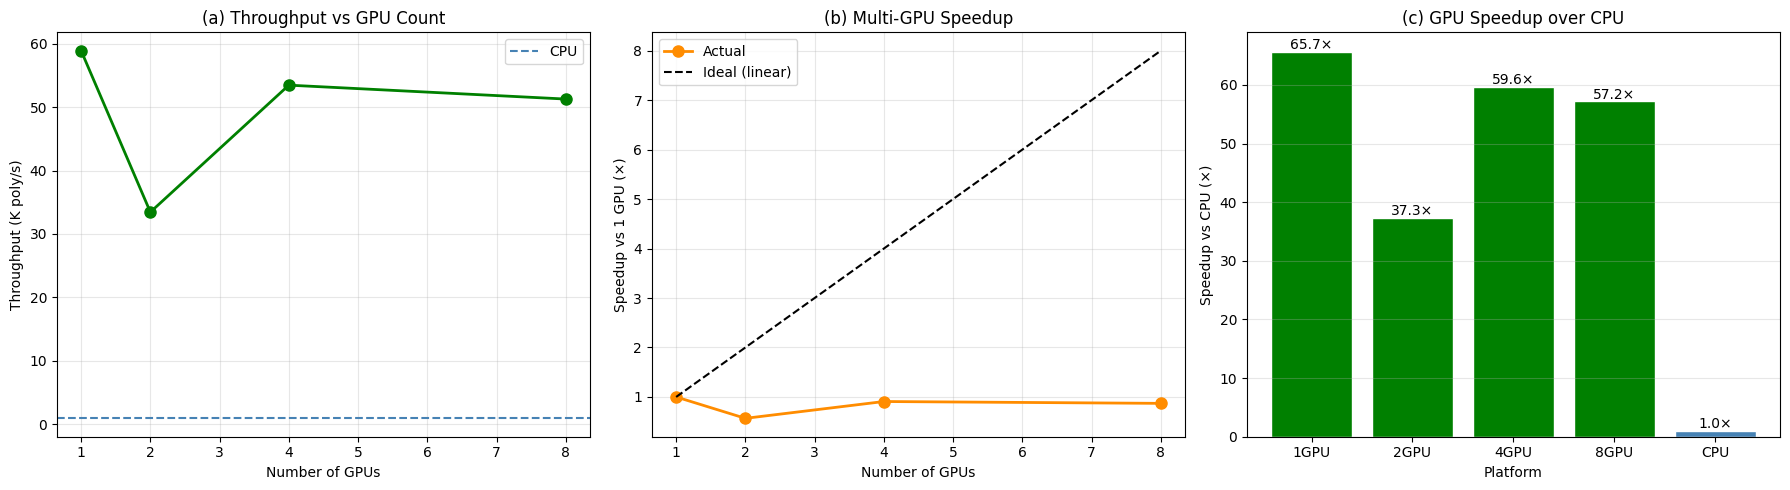

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Throughput vs GPU count
axes[0].plot(bench_df['n_gpus'], bench_df['throughput']/1000,
             'o-', color='green', lw=2, markersize=8)
axes[0].axhline(cpu_tp/1000, color='steelblue', linestyle='--', label='CPU')
axes[0].set_xlabel('Number of GPUs'); axes[0].set_ylabel('Throughput (K poly/s)')
axes[0].set_title('(a) Throughput vs GPU Count')
axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) Speedup vs 1 GPU (ideal = linear)
ideal = bench_df['n_gpus'].values
axes[1].plot(bench_df['n_gpus'], bench_df['speedup_vs_1gpu'],
             'o-', color='darkorange', lw=2, markersize=8, label='Actual')
axes[1].plot(gpu_counts, ideal, 'k--', label='Ideal (linear)')
axes[1].set_xlabel('Number of GPUs'); axes[1].set_ylabel('Speedup vs 1 GPU (×)')
axes[1].set_title('(b) Multi-GPU Speedup')
axes[1].legend(); axes[1].grid(alpha=0.3)

# (c) Speedup vs CPU
axes[2].bar([f'{n}GPU' for n in bench_df['n_gpus']] + ['CPU'],
            list(bench_df['speedup_vs_cpu']) + [1.0],
            color=['green']*len(bench_df) + ['steelblue'], edgecolor='white')
axes[2].set_xlabel('Platform'); axes[2].set_ylabel('Speedup vs CPU (×)')
axes[2].set_title('(c) GPU Speedup over CPU')
axes[2].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(list(bench_df['speedup_vs_cpu']) + [1.0]):
    axes[2].text(i, v+0.5, f'{v:.1f}×', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/multigpu_speedup_plots.png', dpi=150)
plt.show()

## 14. Final Summary

In [38]:
print('=' * 70)
print('  METHOD 1: Cell ID MLP Encoder + NT-Xent — DGX Final Summary')
print('=' * 70)
print(f'\n── Platform ──────────────────────────────────────────────────────')
print(f'  Server     : DGX A100')
print(f'  GPUs       : {NUM_GPUS}× NVIDIA A100-SXM4 (80GB each)')
print(f'  CPU cores  : {NUM_CPUS}')
print(f'\n── Configuration ─────────────────────────────────────────────────')
print(f'  Dataset    : {TOTAL_POLYGONS:,} polygons (40K index / 10K query)')
print(f'  Input      : {VOCAB_SIZE:,}-dim cell ID binary vector')
print(f'  Embed dim  : {EMBED_DIM} | Hidden: {HIDDEN_DIMS}')
print(f'  Loss       : NT-Xent (T={TEMPERATURE}, {BATCH_SIZE-1} negatives/anchor)')
print(f'  Epochs     : {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')
print(f'\n── Training ──────────────────────────────────────────────────────')
avg_gpu  = np.mean(history['gpu_compute_s'])
avg_sync = np.mean(history['sync_overhead_s'])
avg_tot  = np.mean(history['epoch_time_s'])
print(f'  Best val loss           : {best_val_loss:.4f}')
print(f'  Random baseline loss    : {random_baseline:.4f}')
print(f'  Gap below random        : {random_baseline - best_val_loss:.4f}')
print(f'  Avg GPU compute/epoch   : {avg_gpu:.2f}s ({avg_gpu/avg_tot*100:.1f}%)')
print(f'  Avg sync overhead/epoch : {avg_sync:.2f}s ({avg_sync/avg_tot*100:.1f}%)')
print(f'  Total training time     : {sum(history["epoch_time_s"]):.1f}s')
print(f'\n── Retrieval ─────────────────────────────────────────────────────')
for k, r in recall_scores.items():
    print(f'  Recall@{k:2d} : {r*100:.2f}%')
print(f'\n── Inference Timing ──────────────────────────────────────────────')
print(f'  Index encoding (40K) : {index_encode_time:.2f}s')
print(f'  Query encoding (10K) : {query_encode_time:.2f}s')
print(f'  HNSW build           : {build_time:.2f}s')
print(f'  Avg query latency    : {np.mean(query_times)*1000:.3f}ms')
print(f'  P95 query latency    : {np.percentile(query_times,95)*1000:.3f}ms')
print(f'\n── Multi-GPU Speedup ─────────────────────────────────────────────')
for _, row in bench_df.iterrows():
    print(f'  {int(row.n_gpus)} GPU(s) : {row.throughput:.0f} poly/s '
          f'| {row.speedup_vs_1gpu:.2f}× vs 1GPU '
          f'| {row.speedup_vs_cpu:.1f}× vs CPU')
print(f'\n── Output Files ──────────────────────────────────────────────────')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    print(f'  {fname:<50s} {os.path.getsize(fpath)/1024:8.1f} KB')
print('\nDone!')

  METHOD 1: Cell ID MLP Encoder + NT-Xent — DGX Final Summary

── Platform ──────────────────────────────────────────────────────
  Server     : DGX A100
  GPUs       : 8× NVIDIA A100-SXM4 (80GB each)
  CPU cores  : 256

── Configuration ─────────────────────────────────────────────────
  Dataset    : 50,000 polygons (40K index / 10K query)
  Input      : 18,382-dim cell ID binary vector
  Embed dim  : 128 | Hidden: [2048, 1024, 512, 256]
  Loss       : NT-Xent (T=0.07, 4095 negatives/anchor)
  Epochs     : 200 | Batch: 4096 | LR: 0.0003

── Training ──────────────────────────────────────────────────────
  Best val loss           : 5.5955
  Random baseline loss    : 9.0109
  Gap below random        : 3.4155
  Avg GPU compute/epoch   : 0.34s (10.2%)
  Avg sync overhead/epoch : 3.00s (89.8%)
  Total training time     : 667.4s

── Retrieval ─────────────────────────────────────────────────────
  Recall@ 1 : 1.45%
  Recall@ 5 : 5.02%
  Recall@10 : 7.94%
  Recall@20 : 12.11%
  Recall@50 : 2